Name: Dharmraj sodha
Enroll no: 24SOECE13043    

Exercise 1: Implement Simple Linear Regression

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
x=pd.read_csv('computers.csv')
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Units    14 non-null     int64
 1   Minutes  14 non-null     int64
dtypes: int64(2)
memory usage: 352.0 bytes


In [6]:
x.head()

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74


In [4]:
mean_value=x['Minutes'].mean()
mean_value

np.float64(97.21428571428571)

Text(0, 0.5, 'Minutes')

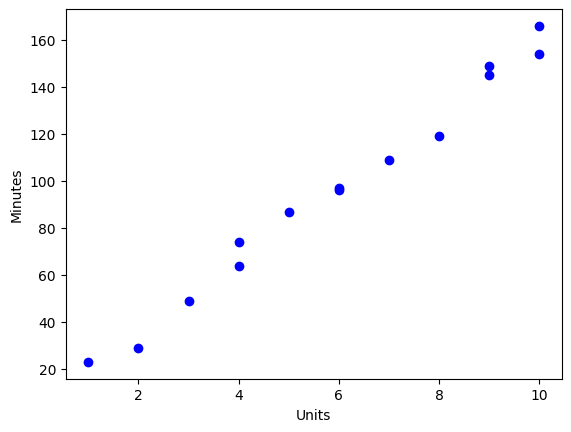

In [5]:
plt.scatter(x['Units'],x['Minutes'],color='blue')
plt.xlabel('Units')
plt.ylabel('Minutes')

create a models

In [12]:
model0 = x['Minutes'].mean()
model1 = 10+12*x['Units']
model2 = 6+18*x['Units']

In [13]:
x['model0'] = model0
x['model1'] = model1
x['model2'] = model2

In [14]:
x.columns

Index(['Units', 'Minutes', 'model0', 'model1', 'model2'], dtype='object')

In [11]:
x

,Units,Minutes,model0,model1,model2
0,1,23,97.214286,286,420
1,2,29,97.214286,358,528
2,3,49,97.214286,598,888
3,4,64,97.214286,778,1158
4,4,74,97.214286,898,1338
5,5,87,97.214286,1054,1572
6,6,96,97.214286,1162,1734
7,6,97,97.214286,1174,1752
8,7,109,97.214286,1318,1968
9,8,119,97.214286,1438,2148


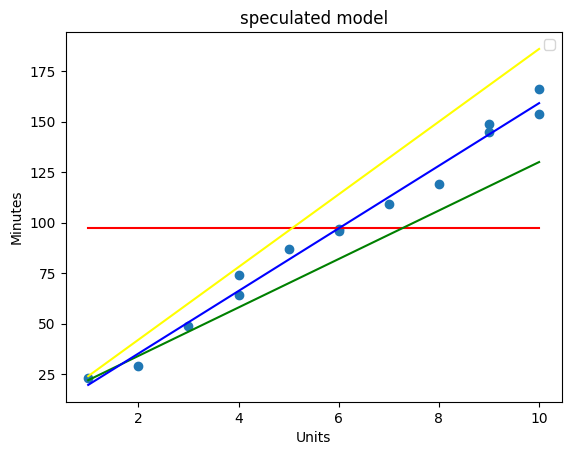

In [30]:
fig,ax = plt.subplots()
ax.scatter(x="Units",y="Minutes",data=x, label='actual repair time')
ax.plot(x['Units'],x['model0'],color="red",label='model0')
ax.plot(x['Units'],x['model1'],color="green",label='model1')
ax.plot(x['Units'],x['model2'],color="yellow",label='model2')
ax.plot(x['Units'],x['model3'],color="blue",label='model3')
ax.set_ylabel("Minutes")
ax.set_xlabel("Units")
ax.set_title("speculated model")
ax.legend("")

build a scikit learn model - linear regression

In [22]:
X = x[['Units']]
Y = x['Minutes']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
print("intercept:",model.intercept_)
print("Coefficient:", model.coef_)

intercept: 4.161654135338296
Coefficient: [15.50877193]


In [27]:
model3 = 4.16+15.50*x['Units']
x['model3'] = model3


In [28]:
x.columns

Index(['Units', 'Minutes', 'model0', 'model1', 'model2', 'model3'], dtype='object')

In [29]:
x

,Units,Minutes,model0,model1,model2,model3
0,1,23,97.214286,22,24,19.66
1,2,29,97.214286,34,42,35.16
2,3,49,97.214286,46,60,50.66
3,4,64,97.214286,58,78,66.16
4,4,74,97.214286,58,78,66.16
5,5,87,97.214286,70,96,81.66
6,6,96,97.214286,82,114,97.16
7,6,97,97.214286,82,114,97.16
8,7,109,97.214286,94,132,112.66
9,8,119,97.214286,106,150,128.16


In [32]:
rsq = model.score(X,Y)

In [34]:
rsq*100

98.74371980620737

Exercise 2: Multiple Linear Regression Model

In [36]:
s = pd.read_csv("std_marks_data.csv")
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     288 non-null    float64
 1   age       300 non-null    int64  
 2   internet  300 non-null    int64  
 3   marks     300 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 9.5 KB


In [37]:
s

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34
...,...,...,...,...
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99


In [44]:
s.isna().sum()

hours       0
age         0
internet    0
marks       0
dtype: int64

In [41]:
s

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34
...,...,...,...,...
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99


In [42]:
s.hours =s.hours.fillna(s.hours.mean())

In [43]:
s

,hours,age,internet,marks
0,6.840000,15,0,78.64
1,6.560000,20,1,88.80
2,5.494514,21,1,88.90
3,8.670000,22,1,98.99
4,7.550000,17,1,92.34
...,...,...,...,...
295,2.990000,25,0,43.45
296,6.550000,15,1,77.74
297,0.000000,20,1,75.76
298,9.900000,22,0,99.99


In [45]:
A = s.iloc[ : , :-1]
A

,hours,age,internet
0,6.840000,15,0
1,6.560000,20,1
2,5.494514,21,1
3,8.670000,22,1
4,7.550000,17,1
...,...,...,...
295,2.990000,25,0
296,6.550000,15,1
297,0.000000,20,1
298,9.900000,22,0


In [48]:
B = s.iloc[:,-1]

In [49]:
B

0      78.64
1      88.80
2      88.90
3      98.99
4      92.34
       ...  
295    43.45
296    77.74
297    75.76
298    99.99
299    99.99
Name: marks, Length: 300, dtype: float64

In [50]:
from sklearn.model_selection import train_test_split
A_train,A_test,B_train,B_test = train_test_split(A,B,test_size=0.3)

In [54]:
A_train.shape

(210, 3)

In [ ]:
A_test.shape

In [55]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(A_train,B_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
print("intercept:", model.intercept_)
print("coefficient:", model.coef_)

intercept: 59.09841982018374
coefficient: [1.52730696 0.20140819 3.45870682]


In [ ]:
hours = int(input("enter study hours:"))
age = int(input("enter age:"))
internet = int(input("enter internet is available or not:"))
data =[[hours,age,internet]]
print(model.predict(data))


Exercise 3: Build Logistic Regression Model

In [2]:
import pandas as pd
h = pd.read_csv("chd_data.csv")
h.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     100 non-null    int64
 1   chd     100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [4]:
h

,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0
...,...,...
95,63,1
96,64,1
97,64,0
98,65,1


In [3]:
h.isna().sum()

age    0
chd    0
dtype: int64

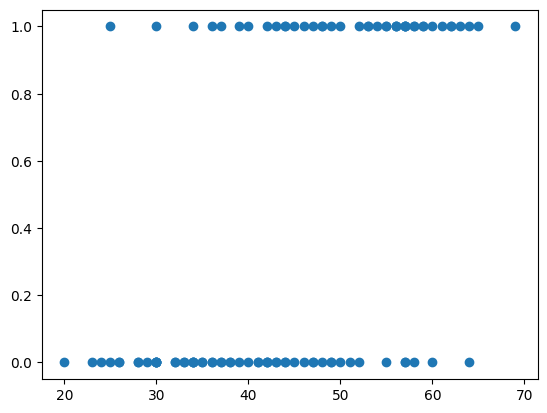

In [8]:
import matplotlib.pyplot as plt
plt.scatter('age','chd',data=h)

In [11]:
X = h[['age']]
Y = h[['chd']]


In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)

c:\laragon\bin\python\python-3.10\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
test=int(input("Enter age:"))
data =[[test]]
print("\n Predicted taget i.e. 'chd' value: ",model.predict(data))


 Predicted taget i.e. 'chd' value:  [0]


c:\laragon\bin\python\python-3.10\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [17]:
print("accuracy score of the model on training data:",model.score(X_train,Y_train))
print("accuracy score of the model on training data:",model.score(X_test,Y_test))

accuracy score of the model on training data: 0.7571428571428571
accuracy score of the model on training data: 0.6666666666666666


Exercise  2 : Multiple Linear Regression Model 
 Std_marks_data.csv
 TO understand multiple Linear Regression , let us contain the student mark dataset
 

In [7]:
student = pd.read_csv("std_marks_data.csv")

In [4]:
student

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34
...,...,...,...,...
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99


In [8]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     288 non-null    float64
 1   age       300 non-null    int64  
 2   internet  300 non-null    int64  
 3   marks     300 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 9.5 KB


In [9]:
student.hours = student.hours.fillna(student.hours.mean())

In [10]:
x=student.iloc[:,:-1]

In [11]:
x

,hours,age,internet
0,6.840000,15,0
1,6.560000,20,1
2,5.494514,21,1
3,8.670000,22,1
4,7.550000,17,1
...,...,...,...
295,2.990000,25,0
296,6.550000,15,1
297,0.000000,20,1
298,9.900000,22,0


In [12]:
student.isna().sum()

hours       0
age         0
internet    0
marks       0
dtype: int64

In [13]:
y = student.iloc[:,-1]

In [14]:
y

0      78.64
1      88.80
2      88.90
3      98.99
4      92.34
       ...  
295    43.45
296    77.74
297    75.76
298    99.99
299    99.99
Name: marks, Length: 300, dtype: float64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [17]:
x_train.shape

(240, 3)

In [18]:
x_test.shape

(60, 3)

In [19]:
y_test.shape

(60,)

In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
print("Intercept=",model.intercept_,"\nCofficients:",model.coef_)

Intercept= 62.81462759970528 
Cofficients: [1.09228604 0.15488439 2.37523335]


In [23]:
hours=int(input("Enter study hours :  "))
age = int(input("Enter age: "))
internet= int(input("Enter internet is available or not (0/1) :"))
data = [[hours,age,internet]]

In [24]:
print(model.predict(data))

[74.84126504]


C:\Users\dharm\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
## Exercise 3 : Build Logistic Regression Model

In [26]:
chd = pd.read_csv("chd_data.csv")

In [27]:
chd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     100 non-null    int64
 1   chd     100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [28]:
print(chd)

    age  chd
0    20    0
1    23    0
2    24    0
3    25    1
4    25    0
..  ...  ...
95   63    1
96   64    1
97   64    0
98   65    1
99   69    1

[100 rows x 2 columns]


In [29]:
chd.isna().sum()

age    0
chd    0
dtype: int64

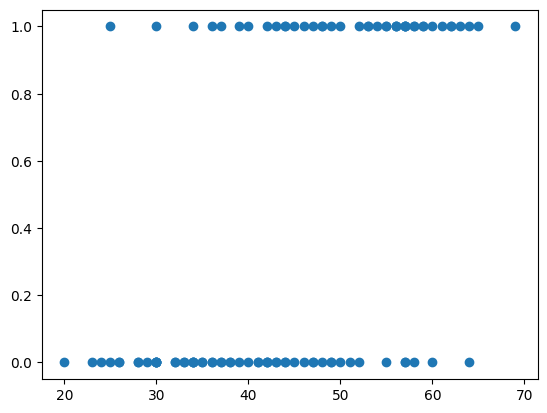

In [30]:
plt.scatter('age','chd',data=chd)

In [31]:
chd

,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0
...,...,...
95,63,1
96,64,1
97,64,0
98,65,1


In [34]:
x = chd[['age']]

In [35]:
y = chd['chd']

In [39]:
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=0)

In [40]:
x_train.shape

(70, 1)

In [41]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
test = int ( input("Enter age: "))
data = [[test]]
print("\nPredicted target i.e. 'chd' value : ", model.predict(data))


Predicted target i.e. 'chd' value :  [0]


C:\Users\dharm\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [45]:
print("Accuray score of the model on training data : ", model.score(x_train,y_train))
print("Accuracy score of the model on test data : ",model.score(x_test,y_test))

Accuray score of the model on training data :  0.7428571428571429
Accuracy score of the model on test data :  0.7333333333333333
